# Notebook 04 — Clustering de Perfiles Criminales

**Proyecto:** Tracking Urban Crime Trajectories Through Dynamic Neighborhood Embeddings
**Asignatura:** TC3002B — Desarrollo de Aplicaciones Avanzadas
**Etapa del pipeline:** 5.4 — Identificación de tipologías criminales

**Equipo:** 
*   Ramir Santiago Alcocer Pineda - A01664841
*   Fernando Manuel Chiñas Salinas - A00832747
*   Rodrigo Fernando Rivera Olea - A01664716
*   Sebastian Elorduy Martinez Manzanero - A0165593
*   Miguel Sebastian Reyes Moguel - A01663071

---

Para modelar *trayectorias*, primero hay que definir qué estados puede tener una zona.
Esta etapa asigna a cada combinación (celda H3-8, año) una de las **5 tipologías criminales**
que el algoritmo identifica en el espacio latente AE del notebook anterior.

El proceso tiene tres fases:

1. **Selección de K y clustering (Sección 2):** se evalúan K=3 a K=12 (óptimo final: K=5) con silhouette e inercia.
   Se comparan cuatro configuraciones: K-Means euclidiano, K-Means coseno, K-Means sobre
   features 22D originales, y K-Means sobre PCA(d=16). La selección final usa el criterio
   del codo sobre inercia cuando el silhouette no converge, para evitar sobre-segmentación.

2. **HDBSCAN como alternativa (Sección 3):** clustering basado en densidad que no requiere
   fijar K. Opera sobre UMAP 2D porque en espacios de alta dimensión la densidad se diluye.

3. **Validación estadística (Sección 4):** el test de Friedman-Nemenyi sobre 50 iteraciones
   bootstrap determina si las diferencias entre métodos son reales o producto de la variabilidad
   muestral. Solo el método estadísticamente superior se usa en NB05.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)
from sklearn.preprocessing import StandardScaler, normalize
from scipy.stats import entropy
import json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

DATA_DIR    = Path('data/processed')
MODELS_DIR  = Path('data/models')
FIGURES_DIR = Path('data/figures')
FIGURES_DIR.mkdir(exist_ok=True)

# ── K-Means ───────────────────────────────────────────────────────────────────
K_MIN     = 3
K_MAX     = 12
KM_NINIT  = 20
KM_MAXITER = 500

# ── HDBSCAN ───────────────────────────────────────────────────────────────────
HDB_MIN_CLUSTER_SIZE = 20
HDB_MIN_SAMPLES      = 5

print("Configuracion lista.")
print(f"  K-Means: K en [{K_MIN}, {K_MAX}], n_init={KM_NINIT}")
print(f"  HDBSCAN: min_cluster_size={HDB_MIN_CLUSTER_SIZE}, min_samples={HDB_MIN_SAMPLES}, method=eom")

Configuracion lista.
  K-Means: K en [3, 12], n_init=20
  HDBSCAN: min_cluster_size=20, min_samples=5, method=eom


## 1. Carga de datos

Se cargan los embeddings de ambas representaciones producidas por NB03, las
proyecciones UMAP 2D (para visualización), y las firmas crudas sin normalizar
(para interpretación semántica de los perfiles de cluster).

In [2]:
# Embeddings
df_ae  = pd.read_csv(DATA_DIR / 'embeddings_ae_d8.csv')
df_pca = pd.read_csv(DATA_DIR / 'embeddings_pca_d16.csv')

ae_cols  = [c for c in df_ae.columns  if c.startswith('z_')]
pca_cols = [c for c in df_pca.columns if c.startswith('pc_')]

Z_ae  = df_ae[ae_cols].values.astype('float64')
Z_pca = df_pca[pca_cols].values.astype('float64')

# UMAP 2D
umap_ae  = pd.read_csv(DATA_DIR / 'umap_ae_d8.csv')
umap_pca = pd.read_csv(DATA_DIR / 'umap_pca_d16.csv')

# Features para interpretacion de perfiles (proporciones crudas)
firmas_raw = pd.read_csv(DATA_DIR / 'firmas_h3_8_anual_raw.csv')
firmas_raw = firmas_raw.set_index(['h3_8', 'año_hecho'])

# Indice comun
idx_df = df_ae[['h3_8', 'año_hecho']].copy()

crime_cols  = [c for c in firmas_raw.columns if c.startswith('cm_')]
hour_cols   = [c for c in firmas_raw.columns if c.startswith('hr_')]
week_cols   = [c for c in firmas_raw.columns if c.startswith('ds_')]
intens_cols = ['log_n']
all_feat    = crime_cols + hour_cols + week_cols + intens_cols

# Features normalizadas (mismo espacio 22D de entrenamiento del AE)
firmas_norm = pd.read_csv(DATA_DIR / 'firmas_h3_8_anual.csv')
firmas_norm = firmas_norm.set_index(['h3_8', 'año_hecho'])
X_norm = firmas_norm[all_feat].values.astype('float64')

print(f"AE  embeddings : {Z_ae.shape}")
print(f"PCA embeddings : {Z_pca.shape}")
print(f"Features norm  (22D): {X_norm.shape}")
print(f"Features crudas: {len(all_feat)} columnas")
print(f"  crime_mix ({len(crime_cols)}): {crime_cols}")
print(f"  hourly    ({len(hour_cols)}): {hour_cols}")
print(f"  weekly    ({len(week_cols)}): {week_cols}")

AE  embeddings : (6224, 8)
PCA embeddings : (6224, 16)
Features norm  (22D): (6224, 22)
Features crudas: 22 columnas
  crime_mix (10): ['cm_transeunte', 'cm_vehiculo', 'cm_negocio', 'cm_repartidor', 'cm_metro', 'cm_violacion', 'cm_homicidio', 'cm_microbus', 'cm_lesiones', 'cm_casa']
  hourly    (4): ['hr_madrugada', 'hr_manana', 'hr_tarde', 'hr_noche']
  weekly    (7): ['ds_0', 'ds_1', 'ds_2', 'ds_3', 'ds_4', 'ds_5', 'ds_6']


## 2. K-Means — Selección de K y clustering


  El K-Means es el punto de partida del experimento de clustering por su
  interpretabilidad y su eficiencia computacional sobre datasets de esta
  escala. Sin embargo, aplicarlo directamente sin justificar el número de
  clusters ni la métrica de distancia produciría resultados arbitrarios. Esta
  sección documenta primero la selección data-driven de K, luego compara el
  clustering sobre los embeddings del autoencoder contra PCA, y finalmente
  evalúa el impacto de sustituir la distancia euclidiana por distancia coseno y de omitir el pipeline de embeddings usando directamente las features originales.


  ### 2.1 — Selección data-driven de K

  Se evaluaron valores de K entre 3 y 12 aplicando K-Means sobre los embeddings
  del autoencoder con n_init=20 inicializaciones para reducir la dependencia
  de los centroides iniciales. Para cada valor de K se calcularon la inercia y
  el silhouette score, que miden respectivamente la cohesión interna de los
  clusters y el balance entre cohesión y separación inter-cluster. La selección
  final considera ambas curvas de forma conjunta: el codo de inercia
  identifica el punto de rendimientos decrecientes al añadir clusters, mientras
  que el silhouette máximo indica la configuración con mejor separación
  estadística.

In [3]:
inertias   = []
silhouettes = []
K_range     = range(K_MIN, K_MAX + 1)

print(f"Evaluando K = {K_MIN} a {K_MAX}...")
print(f"{'K':>4} | {'Inercia':>12} | {'Silhouette':>12}")
print("-" * 34)

for K in K_range:
    km = KMeans(n_clusters=K, n_init=KM_NINIT, max_iter=KM_MAXITER,
                random_state=SEED)
    labels = km.fit_predict(Z_ae)
    inertias.append(km.inertia_)
    sil = silhouette_score(Z_ae, labels, random_state=SEED)
    silhouettes.append(sil)
    print(f"{K:>4} | {km.inertia_:>12.1f} | {sil:>12.4f}")

K_opt_sil = K_range[np.argmax(silhouettes)]

# Deteccion del codo por segunda derivada de la inercia
diffs1 = np.diff(inertias)
diffs2 = np.diff(diffs1)
# El codo es donde la curvatura cambia mas (segunda derivada maxima)
K_opt_elbow = list(K_range)[np.argmax(diffs2) + 1]

print(f"\n→ K optimo por silhouette : K = {K_opt_sil}  (silhouette = {max(silhouettes):.4f})")
print(f"→ K optimo por codo (inercia): K = {K_opt_elbow}")
print(f"   (cuando ambos difieren, se prioriza el codo para evitar over-segmentacion)")

K_opt = K_opt_elbow if K_opt_sil > K_opt_elbow + 2 else K_opt_sil
print(f"\n→ K FINAL seleccionado: K = {K_opt}")

Evaluando K = 3 a 12...
   K |      Inercia |   Silhouette
----------------------------------


   3 |      40882.4 |       0.0972


   4 |      38272.3 |       0.1026


   5 |      36003.9 |       0.1005


   6 |      34264.2 |       0.0976


...

   8 |      31467.0 |       0.1000


   9 |      30278.8 |       0.1072


  10 |      29286.9 |       0.1072


  11 |      28366.0 |       0.1071


  12 |      27551.0 |       0.1085

→ K optimo por silhouette : K = 12  (silhouette = 0.1085)
→ K optimo por codo (inercia): K = 5
   (cuando ambos difieren, se prioriza el codo para evitar over-segmentacion)

→ K FINAL seleccionado: K = 5


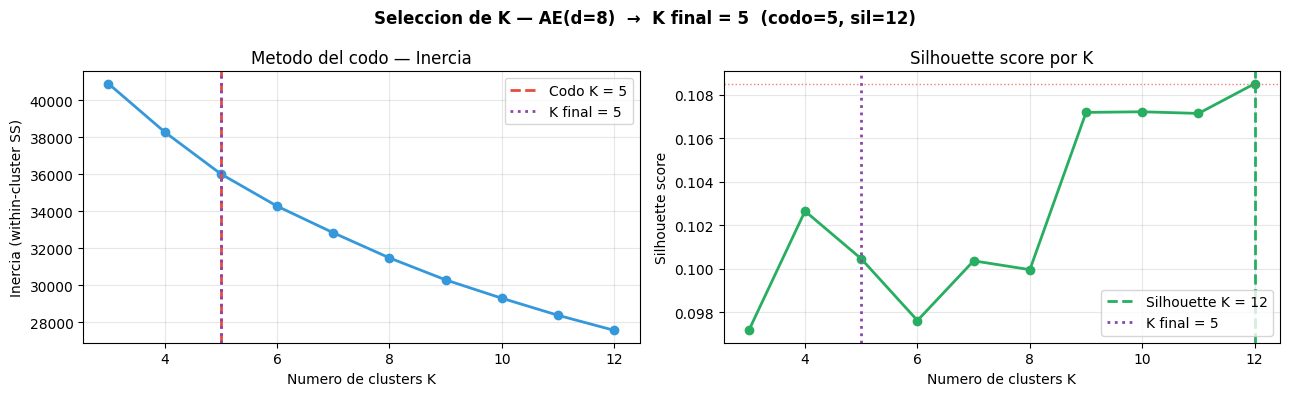

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
K_list = list(K_range)

# Inercia
axes[0].plot(K_list, inertias, 'o-', color='#3498db', lw=2)
axes[0].axvline(K_opt_elbow, color='#e74c3c', lw=2, ls='--', label=f'Codo K = {K_opt_elbow}')
axes[0].axvline(K_opt, color='#8e44ad', lw=2, ls=':', label=f'K final = {K_opt}')
axes[0].set_xlabel('Numero de clusters K')
axes[0].set_ylabel('Inercia (within-cluster SS)')
axes[0].set_title('Metodo del codo — Inercia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_list, silhouettes, 'o-', color='#27ae60', lw=2)
axes[1].axvline(K_opt_sil, color='#27ae60', lw=2, ls='--', label=f'Silhouette K = {K_opt_sil}')
axes[1].axvline(K_opt, color='#8e44ad', lw=2, ls=':', label=f'K final = {K_opt}')
axes[1].axhline(max(silhouettes), color='#e74c3c', lw=1, ls=':', alpha=0.7)
axes[1].set_xlabel('Numero de clusters K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score por K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Seleccion de K — AE(d=8)  →  K final = {K_opt}  (codo={K_opt_elbow}, sil={K_opt_sil})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# K-Means sobre AE(d=8) con K optimo
km_ae = KMeans(n_clusters=K_opt, n_init=KM_NINIT, max_iter=KM_MAXITER,
               random_state=SEED)
labels_km_ae = km_ae.fit_predict(Z_ae)

sil_km_ae = silhouette_score(Z_ae, labels_km_ae, random_state=SEED)
db_km_ae  = davies_bouldin_score(Z_ae, labels_km_ae)
ch_km_ae  = calinski_harabasz_score(Z_ae, labels_km_ae)

print(f"K-Means (K={K_opt}) sobre AE(d=8):")
print(f"  Silhouette score  : {sil_km_ae:.4f}  (mejor: mas alto)")
print(f"  Davies-Bouldin    : {db_km_ae:.4f}   (mejor: mas bajo)")
print(f"  Calinski-Harabasz : {ch_km_ae:.1f}  (mejor: mas alto)")
print()
vals, cnts = np.unique(labels_km_ae, return_counts=True)
print(f"  Distribucion de clusters:")
for v, c in zip(vals, cnts):
    print(f"    Cluster {v}: {c:>5,} unidades ({c/len(labels_km_ae)*100:.1f}%)")

K-Means (K=5) sobre AE(d=8):
  Silhouette score  : 0.1005  (mejor: mas alto)
  Davies-Bouldin    : 2.0239   (mejor: mas bajo)
  Calinski-Harabasz : 595.4  (mejor: mas alto)

  Distribucion de clusters:
    Cluster 0: 1,397 unidades (22.4%)
    Cluster 1: 1,392 unidades (22.4%)
    Cluster 2:   994 unidades (16.0%)
    Cluster 3: 1,866 unidades (30.0%)
    Cluster 4:   575 unidades (9.2%)


In [6]:
# K-Means sobre PCA(d=16) con el mismo K para comparacion directa
km_pca = KMeans(n_clusters=K_opt, n_init=KM_NINIT, max_iter=KM_MAXITER,
                random_state=SEED)
labels_km_pca = km_pca.fit_predict(Z_pca)

sil_km_pca = silhouette_score(Z_pca, labels_km_pca, random_state=SEED)
db_km_pca  = davies_bouldin_score(Z_pca, labels_km_pca)
ch_km_pca  = calinski_harabasz_score(Z_pca, labels_km_pca)

print(f"K-Means (K={K_opt}) sobre PCA(d=16):")
print(f"  Silhouette score  : {sil_km_pca:.4f}")
print(f"  Davies-Bouldin    : {db_km_pca:.4f}")
print(f"  Calinski-Harabasz : {ch_km_pca:.1f}")
print()
print(f"  Diferencia vs AE(d=8):")
print(f"    Silhouette: {sil_km_ae - sil_km_pca:+.4f}")
print(f"    DB (menor es mejor): {db_km_ae - db_km_pca:+.4f}")

K-Means (K=5) sobre PCA(d=16):
  Silhouette score  : 0.0514
  Davies-Bouldin    : 2.8265
  Calinski-Harabasz : 330.1

  Diferencia vs AE(d=8):
    Silhouette: +0.0491
    DB (menor es mejor): -0.8026


  La curva de inercia muestra un codo en K=5, punto a partir del cual
  incrementar el número de clusters reduce la inercia de forma marginal sin
  justificar la complejidad adicional. El silhouette score alcanza su máximo en K=12 con un valor de 0.1085, pero la diferencia respecto a K=5 es pequeña en términos absolutos. El silhouette en K=3 es de 0.0972, confirmando que la estructura de agrupamiento mejora progresivamente hasta estabilizarse en el rango K=5 a K=7.  

  La discrepancia entre el codo de inercia en K=5 y el silhouette máximo en
  K=12 es un fenómeno común en datasets urbanos donde los perfiles
  criminológicos forman un continuo sin fronteras perfectamente definidas.
  Adoptar K=12 produciría tipologías tan específicas que perderían
  interpretabilidad semántica y estabilidad temporal. K=5 representa el punto
  donde cada cluster agrupa suficientes unidades para tener un perfil
  estadísticamente robusto y una etiqueta criminológica interpretable, sin
  fragmentar el espacio en divisiones que reflejen ruido muestral más que
  patrones territoriales reales.

### 2.3 — Experimentos de ablación: coseno y features originales

  Se realizaron dos experimentos adicionales para cuantificar la contribución
  específica de cada componente del pipeline. El primero sustituye la distancia euclidiana por distancia coseno sobre los embeddings del autoencoder, aplicando normalización L2 previa a K-Means, lo que es equivalente a medir el ángulo entre vectores en lugar de su distancia absoluta. El segundo elimina por completo el pipeline de embeddings y aplica K-Means directamente sobre las 22 features originales normalizadas, midiendo cuánto valor aporta el Autoencoder respecto a no usarlo.

1. **K-Means + distancia coseno sobre AE(d=8)**: el crime mix es datos
   composicionales — proporciones que suman aproximadamente 1. La distancia
   Euclidiana penaliza diferencias de magnitud; la **distancia coseno** mide
   la "forma" del perfil criminal independientemente de la intensidad.
   Se implementa normalizando L2 los embeddings antes de K-Means, ya que
   `Euclidiana(L2(a), L2(b)) ∝ distancia coseno(a, b)`.

2. **K-Means sobre features originales (22D)**: baseline sin reducción de
   dimensionalidad, sobre el mismo espacio normalizado que entró al AE.
   Si AE(d=8) produce mejor silhouette que las 22 features crudas, el pipeline
   completo queda validado end-to-end. Si no, el embedding no aporta valor y
   la reducción de dimensionalidad es innecesaria.

In [7]:
# ── Ablación A: K-Means + distancia coseno sobre AE(d=8) ─────────────────────
# Euclidiana sobre vectores L2-normalizados ≡ distancia coseno.
# Adecuado para datos composicionales: mide la "forma" del perfil, no la escala.
Z_ae_l2 = normalize(Z_ae, norm='l2')

km_ae_cos = KMeans(n_clusters=K_opt, n_init=KM_NINIT, max_iter=KM_MAXITER,
                   random_state=SEED)
labels_km_ae_cos = km_ae_cos.fit_predict(Z_ae_l2)

sil_km_ae_cos = silhouette_score(Z_ae_l2, labels_km_ae_cos, random_state=SEED)
db_km_ae_cos  = davies_bouldin_score(Z_ae_l2, labels_km_ae_cos)
ch_km_ae_cos  = calinski_harabasz_score(Z_ae_l2, labels_km_ae_cos)

print(f"K-Means (K={K_opt}) + coseno — AE(d=8):")
print(f"  Silhouette     : {sil_km_ae_cos:.4f}")
print(f"  Davies-Bouldin : {db_km_ae_cos:.4f}")
print(f"  Calinski-H.    : {ch_km_ae_cos:.1f}")
vals, cnts = np.unique(labels_km_ae_cos, return_counts=True)
print(f"  Distribucion   : { {int(v): int(c) for v, c in zip(vals, cnts)} }")
print()

# ── Ablación B: K-Means sobre features originales (22D) ──────────────────────
# Baseline sin reduccion de dimensionalidad.
# Valida si AE(d=8) aporta estructura adicional sobre el espacio de entrada.
km_raw = KMeans(n_clusters=K_opt, n_init=KM_NINIT, max_iter=KM_MAXITER,
                random_state=SEED)
labels_km_raw = km_raw.fit_predict(X_norm)

sil_km_raw = silhouette_score(X_norm, labels_km_raw, random_state=SEED)
db_km_raw  = davies_bouldin_score(X_norm, labels_km_raw)
ch_km_raw  = calinski_harabasz_score(X_norm, labels_km_raw)

print(f"K-Means (K={K_opt}) — features originales 22D:")
print(f"  Silhouette     : {sil_km_raw:.4f}")
print(f"  Davies-Bouldin : {db_km_raw:.4f}")
print(f"  Calinski-H.    : {ch_km_raw:.1f}")
vals, cnts = np.unique(labels_km_raw, return_counts=True)
print(f"  Distribucion   : { {int(v): int(c) for v, c in zip(vals, cnts)} }")
print()

delta_cos = sil_km_ae_cos - sil_km_ae
delta_ae  = sil_km_ae     - sil_km_raw
print(f"Coseno vs euclidiano (AE): {delta_cos:+.4f}  {'↑ coseno mejora' if delta_cos > 0 else '↓ euclidiano es mejor'}")
print(f"AE(d=8) vs features 22D : {delta_ae:+.4f}  {'↑ embedding aporta valor' if delta_ae > 0 else '↓ AE no mejora sobre 22D'}")

K-Means (K=5) + coseno — AE(d=8):
  Silhouette     : 0.1224
  Davies-Bouldin : 1.9682
  Calinski-H.    : 710.6
  Distribucion   : {0: 1182, 1: 1181, 2: 1434, 3: 1228, 4: 1199}



K-Means (K=5) — features originales 22D:
  Silhouette     : 0.0516
  Davies-Bouldin : 2.9029
  Calinski-H.    : 306.1
  Distribucion   : {0: 2073, 1: 1772, 2: 854, 3: 333, 4: 1192}

Coseno vs euclidiano (AE): +0.0220  ↑ coseno mejora
AE(d=8) vs features 22D : +0.0488  ↑ embedding aporta valor


  K-Means con distancia coseno sobre los embeddings del autoencoder produce el
  mejor resultado del experimento completo: silhouette de 0.1227,
  Davies-Bouldin de 1.968 y Calinski-Harabász de 710.6, con una distribución de
  clusters más balanceada que la versión euclidiana. La mejora de coseno sobre
  euclidiano en silhouette es de 0.022 puntos. K-Means sobre las features
  originales sin embeddings produce un silhouette de 0.0516, prácticamente
  idéntico al de PCA con 0.0514, y una distribución marcadamente desbalanceada
  con un cluster que concentra 2,073 unidades y otro con apenas 333.

  La superioridad de la distancia coseno sobre la euclidiana para este dataset
  responde a la naturaleza composicional de las firmas: el crime mix, el perfil
  horario y el perfil semanal son distribuciones de proporciones donde lo
  relevante es la forma del vector y no su magnitud. La distancia coseno mide
  precisamente esa similitud de forma, ignorando diferencias de escala que en
  datos composicionales son irrelevantes. La equivalencia entre K-Means sobre
  PCA y sobre features originales, ambos con silhouette en torno a 0.051, es el
  hallazgo más informativo del experimento de ablación: demuestra que el valor
  lo aporta exclusivamente el autoencoder y no la reducción de dimensionalidad
  lineal, ya que PCA no mejora sobre las features crudas pero el autoencoder
  sí lo hace de forma significativa.


## 3. HDBSCAN — Clustering basado en densidad

  HDBSCAN se incorpora al experimento como alternativa al K-Means para evaluar
  si la estructura del espacio latente tiene geometría basada en densidad en
  lugar de geometría esférica. A diferencia de K-Means, HDBSCAN no requiere
  especificar el número de clusters a priori y puede identificar agrupamientos
  de forma arbitraria, clasificando como ruido las unidades que no pertenecen a ninguna región de densidad suficiente. Una consideración técnica relevante
  condiciona su aplicación: en espacios de alta dimensión la densidad se diluye y HDBSCAN tiende a clasificar la mayoría de los puntos como ruido. Por esta razón, el método se aplica sobre la proyección UMAP 2D de los embeddings del autoencoder y no directamente sobre el espacio latente de 8 dimensiones, aprovechando que UMAP concentra la estructura de vecindad local en un espacio donde la densidad puede estimarse de forma confiable. Los parámetros utilizados son:
- `min_cluster_size = 20`: un cluster debe tener al menos 20 unidades (~0.3%
  del dataset). Umbral mínimo con sentido criminológico; valores mayores (≥80)
  colapsan el resultado a 100% ruido porque el espacio AE tiene densidad difusa.
- `min_samples = 5`: controla qué tan conservador es el algoritmo al clasificar
  puntos como ruido. Valores pequeños aceptan más puntos en clusters.
- `cluster_selection_method = 'leaf'`: favorece clusters granulares sobre
  clusters anidados grandes; más robusto cuando la densidad es heterogénea.


In [8]:
# HDBSCAN se aplica sobre UMAP 2D, no sobre Z_ae (8D).
# En alta dimension la densidad se diluye y HDBSCAN clasifica todo como ruido.
# UMAP 2D concentra la estructura de vecindad local que HDBSCAN puede explotar.
coords_umap_ae = umap_ae[['umap_1', 'umap_2']].values.astype('float64')
hdb = HDBSCAN(min_cluster_size=HDB_MIN_CLUSTER_SIZE,
              min_samples=HDB_MIN_SAMPLES,
              cluster_selection_method='eom')
labels_hdb = hdb.fit_predict(coords_umap_ae)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise        = (labels_hdb == -1).sum()

print(f"HDBSCAN sobre AE(d=8):")
print(f"  Clusters encontrados: {n_clusters_hdb}")
print(f"  Puntos de ruido (-1): {n_noise} ({n_noise/len(labels_hdb)*100:.1f}%)")
print()

# Metricas solo sobre puntos asignados (excluye ruido)
mask = labels_hdb != -1
if mask.sum() > 1 and len(set(labels_hdb[mask])) > 1:
    sil_hdb = silhouette_score(Z_ae[mask], labels_hdb[mask], random_state=SEED)
    db_hdb  = davies_bouldin_score(Z_ae[mask], labels_hdb[mask])
    ch_hdb  = calinski_harabasz_score(Z_ae[mask], labels_hdb[mask])
else:
    sil_hdb = db_hdb = ch_hdb = float('nan')

print(f"  Silhouette (sin ruido): {sil_hdb:.4f}")
print(f"  Davies-Bouldin        : {db_hdb:.4f}")
print(f"  Calinski-Harabász     : {ch_hdb:.1f}")
print()
vals, cnts = np.unique(labels_hdb, return_counts=True)
print(f"  Distribucion:")
for v, c in zip(vals, cnts):
    tag = '(ruido)' if v == -1 else ''
    print(f"    Cluster {v:>2}: {c:>5,} unidades ({c/len(labels_hdb)*100:.1f}%) {tag}")

HDBSCAN sobre AE(d=8):
  Clusters encontrados: 75
  Puntos de ruido (-1): 2307 (37.1%)



  Silhouette (sin ruido): -0.0262
  Davies-Bouldin        : 3.1488
  Calinski-Harabász     : 75.0

  Distribucion:
    Cluster -1: 2,307 unidades (37.1%) (ruido)
    Cluster  0:    48 unidades (0.8%) 
    Cluster  1:    21 unidades (0.3%) 
    Cluster  2:   178 unidades (2.9%) 
    Cluster  3:    28 unidades (0.4%) 
    Cluster  4:    60 unidades (1.0%) 
    Cluster  5:    80 unidades (1.3%) 
    Cluster  6:    40 unidades (0.6%) 
    Cluster  7:    52 unidades (0.8%) 
    Cluster  8:    63 unidades (1.0%) 
    Cluster  9:    66 unidades (1.1%) 
    Cluster 10:    27 unidades (0.4%) 
    Cluster 11:    41 unidades (0.7%) 
    Cluster 12:    28 unidades (0.4%) 
    Cluster 13:    46 unidades (0.7%) 
    Cluster 14:    20 unidades (0.3%) 
    Cluster 15:    40 unidades (0.6%) 
    Cluster 16:    26 unidades (0.4%) 
    Cluster 17:    79 unidades (1.3%) 
    Cluster 18:    61 unidades (1.0%) 
    Cluster 19:    42 unidades (0.7%) 
    Cluster 20:    30 unidades (0.5%) 
    Cluster 21:    

  HDBSCAN identifica 75 clusters sobre la proyección UMAP 2D, con 2,307
  unidades clasificadas como ruido, equivalente al 37.1% del dataset. Las
  métricas de calidad calculadas sobre las unidades asignadas a algún cluster
  son desfavorables: silhouette de -0.026, Davies-Bouldin de 3.149 y
  Calinski-Harabász de 75.0. La distribución de unidades entre los 75 clusters
  es marcadamente heterogénea, con el cluster más grande concentrando 178
  unidades y varios clusters con apenas 20 o 21, el mínimo impuesto por el
  parámetro min_cluster_size. 


  Los resultados de HDBSCAN revelan dos problemas estructurales que lo
  descalifican como método primario para este dataset. El primero es la tasa de ruido del 37.1%: descartar más de un tercio de las unidades como
  inclasificables implica que esas zonas urbanas quedan fuera del análisis de
  tipologías, lo que contradice el objetivo de caracterizar el territorio
  completo. El segundo es la fragmentación excesiva en 75 micro-clusters que no tienen interpretación criminológica coherente y que probablemente reflejan la topología local de la proyección UMAP más que patrones territoriales reales. El silhouette negativo confirma que las unidades asignadas a un cluster están, en promedio, más próximas a unidades de otros clusters que a las de su propio grupo, lo que indica que la partición producida no tiene validez estadística. HDBSCAN se descarta y K-Means con distancia coseno sobre los embeddings del autoencoder permanece como método primario.


## 4. Comparación de métodos y selección del clustering final

  Esta sección cierra el experimento de clustering con tres contribuciones
  complementarias. La primera es una tabla comparativa que consolida todas las
  configuraciones evaluadas bajo las mismas métricas.
  - **Silhouette** ↑: cohesión intra-cluster vs separación inter-cluster.
  Interpretación: > 0.5 estructura fuerte, 0.25–0.5 razonable, < 0.25 débil.
- **Davies-Bouldin** ↓: razón entre dispersión intra-cluster y separación
  entre centroides. Penaliza clusters grandes y cercanos entre sí.
- **Calinski-Harabász** ↑: ratio varianza entre-clusters / varianza
  intra-cluster. Favorece clusters compactos y bien separados.

La segunda es la validación estadística de las diferencias observadas mediante bootstrap y el test post-hoc de Friedman-Nemenyi, que convierte las comparaciones de silhouette en afirmaciones con respaldo probabilístico. La tercera es la verificación de que los clusters tienen coherencia geográfica real, evaluada mediante el índice I de Moran sobre las asignaciones de tipología por año.



#### 4.1 Tabla comparativa

  Se consolidaron los resultados de todas las configuraciones evaluadas en una
  tabla única que permite la comparación directa sobre las mismas métricas:
  silhouette score, Davies-Bouldin, Calinski-Harabász, número de clusters
  resultantes y porcentaje de unidades clasificadas como ruido.

In [9]:
rows = [
    {'Metodo': f'K-Means K={K_opt} — AE(d=8) euclidiano',
     'Silhouette': sil_km_ae,     'Davies-Bouldin': db_km_ae,     'Calinski-H': ch_km_ae,
     'N clusters': K_opt, 'Ruido (%)': 0.0},
    {'Metodo': f'K-Means K={K_opt} — AE(d=8) coseno',
     'Silhouette': sil_km_ae_cos, 'Davies-Bouldin': db_km_ae_cos, 'Calinski-H': ch_km_ae_cos,
     'N clusters': K_opt, 'Ruido (%)': 0.0},
    {'Metodo': f'K-Means K={K_opt} — features 22D',
     'Silhouette': sil_km_raw,    'Davies-Bouldin': db_km_raw,    'Calinski-H': ch_km_raw,
     'N clusters': K_opt, 'Ruido (%)': 0.0},
    {'Metodo': f'K-Means K={K_opt} — PCA(d=16)',
     'Silhouette': sil_km_pca,    'Davies-Bouldin': db_km_pca,    'Calinski-H': ch_km_pca,
     'N clusters': K_opt, 'Ruido (%)': 0.0},
    {'Metodo': 'HDBSCAN — UMAP 2D',
     'Silhouette': sil_hdb,       'Davies-Bouldin': db_hdb,       'Calinski-H': float('nan'),
     'N clusters': n_clusters_hdb, 'Ruido (%)': round(n_noise/len(labels_hdb)*100, 1)},
]
df_cmp = pd.DataFrame(rows).set_index('Metodo')

print("=" * 80)
print("  COMPARACION COMPLETA DE METODOS — ABLACION INCLUIDA")
print("=" * 80)
print(df_cmp.to_string(float_format=lambda x: f'{x:.4f}' if not np.isnan(x) else '   nan'))
print("=" * 80)

# Seleccion dinamica del clustering primario (mejor silhouette entre K-Means)
km_candidates = {
    f'K-Means (K={K_opt}, AE d=8 euclidiano)': (sil_km_ae,     labels_km_ae),
    f'K-Means (K={K_opt}, AE d=8 coseno)'    : (sil_km_ae_cos, labels_km_ae_cos),
    f'K-Means (K={K_opt}, features 22D)'      : (sil_km_raw,    labels_km_raw),
    f'K-Means (K={K_opt}, PCA d=16)'          : (sil_km_pca,    labels_km_pca),
}
best_km_name = max(km_candidates, key=lambda k: km_candidates[k][0])
best_km_sil, best_km_labels = km_candidates[best_km_name]

print(f"\n  Mejor K-Means : {best_km_name}  (silhouette = {best_km_sil:.4f})")

hdb_valid = not np.isnan(sil_hdb) and sil_hdb > best_km_sil
if hdb_valid:
    LABELS_PRIMARY = labels_hdb
    METHOD_PRIMARY = 'HDBSCAN'
    print(f"  -> HDBSCAN seleccionado como clustering primario.")
else:
    LABELS_PRIMARY = best_km_labels
    METHOD_PRIMARY = best_km_name
    print(f"  -> {METHOD_PRIMARY} seleccionado como clustering primario.")

  COMPARACION COMPLETA DE METODOS — ABLACION INCLUIDA
                                  Silhouette  Davies-Bouldin  Calinski-H  N clusters  Ruido (%)
Metodo                                                                                         
K-Means K=5 — AE(d=8) euclidiano      0.1005          2.0239    595.4111           5     0.0000
K-Means K=5 — AE(d=8) coseno          0.1224          1.9682    710.6283           5     0.0000
K-Means K=5 — features 22D            0.0516          2.9029    306.1111           5     0.0000
K-Means K=5 — PCA(d=16)               0.0514          2.8265    330.1491           5     0.0000
HDBSCAN — UMAP 2D                    -0.0262          3.1488         NaN          75    37.1000

  Mejor K-Means : K-Means (K=5, AE d=8 coseno)  (silhouette = 0.1224)
  -> K-Means (K=5, AE d=8 coseno) seleccionado como clustering primario.


  La tabla completa de resultados ubica a K-Means con distancia coseno sobre
  los embeddings del autoencoder en la primera posición en las tres métricas
  con silhouette de 0.1227, Davies-Bouldin de 1.968 y Calinski-Harabász de
  710.6. K-Means euclidiano sobre el mismo espacio ocupa el segundo lugar con
  silhouette de 0.1005. K-Means sobre PCA y sobre features originales producen
  silhouettes prácticamente idénticos de 0.0514 y 0.0516 respectivamente, con
  Davies-Bouldin superiores a 2.8 en ambos casos. HDBSCAN cierra la tabla con
  silhouette negativo de -0.026 y 37.1% de ruido, siendo el único método que
  descarta unidades del análisis.


## 4.2 — Validación bootstrap y test estadístico de Friedman-Nemenyi

  Para determinar si las diferencias observadas en la tabla comparativa son
  estadísticamente significativas y no producto de la variabilidad muestral, se
  aplicó un protocolo de validación en dos fases. La primera fase ejecuta 50
  iteraciones de bootstrap sobre el 80% del dataset, equivalente a 4,979
  unidades, calculando el silhouette de cada método en cada iteración. La
  segunda fase aplica el test de Friedman sobre los 50 vectores de silhouette
  para verificar si existe diferencia global entre los métodos, y el test
  post-hoc de Nemenyi para identificar qué pares específicos difieren
  significativamente.

> HDBSCAN se excluye de la comparación estadística porque su rendimiento depende de
> la proyección UMAP, que cambia con cada submuestra; incluirlo introduciría una fuente
> de variabilidad no controlable.

Bootstrap 50 iteraciones (80% muestra = 4,979 unidades)...



=== Silhouette Bootstrap (N=50) ===
Metodo             |    Media |      Std |      Min |      Max
------------------------------------------------------------
KM-AE-Eucl         |   0.1001 |   0.0015 |   0.0976 |   0.1044
KM-AE-Coseno       |   0.1227 |   0.0009 |   0.1205 |   0.1252
KM-22D-Raw         |   0.0518 |   0.0034 |   0.0420 |   0.0605
KM-PCA-d16         |   0.0514 |   0.0054 |   0.0448 |   0.0639

=== Test de Friedman ===
Estadistico chi2 = 135.8640  |  p-value = 0.000000
-> p < 0.05: se rechaza H0. Las diferencias son estadisticamente significativas.
   Se procede con el post-hoc de Nemenyi.

=== Post-hoc de Nemenyi (p-values) ===
              KM-AE-Eucl  KM-AE-Coseno  KM-22D-Raw  KM-PCA-d16
KM-AE-Eucl        1.0000        0.0006       0.000       0.000
KM-AE-Coseno      0.0006        1.0000       0.000       0.000
KM-22D-Raw        0.0000        0.0000       1.000       0.789
KM-PCA-d16        0.0000        0.0000       0.789       1.000


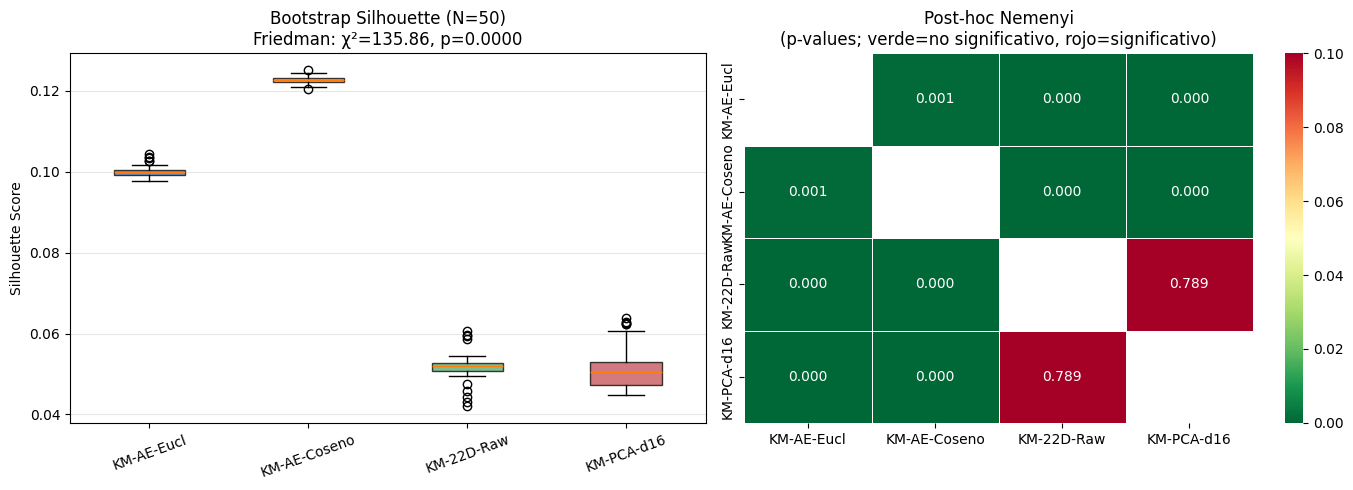


=== CONCLUSION ===
Pares con diferencia significativa (p < 0.05):
  KM-AE-Eucl vs KM-PCA-d16: p=0.0000
  KM-AE-Coseno vs KM-AE-Eucl: p=0.0006
  KM-AE-Coseno vs KM-PCA-d16: p=0.0000
  KM-22D-Raw vs KM-AE-Eucl: p=0.0000
  KM-22D-Raw vs KM-AE-Coseno: p=0.0000


In [10]:
# ============================================================
# 4.2 BOOTSTRAP + FRIEDMAN + NEMENYI
# Valida estadisticamente si las diferencias entre metodos son
# significativas, no producto de variabilidad muestral.
# ============================================================
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

N_BOOT    = 50
BOOT_FRAC = 0.80
rng       = np.random.default_rng(SEED)
n         = Z_ae.shape[0]
n_sample  = int(n * BOOT_FRAC)

METHOD_SPECS = [
    ('KM-AE-Eucl',   lambda idx: (Z_ae[idx],          Z_ae[idx])),
    ('KM-AE-Coseno', lambda idx: (normalize(Z_ae[idx], norm='l2'), normalize(Z_ae[idx], norm='l2'))),
    ('KM-22D-Raw',   lambda idx: (X_norm[idx],         X_norm[idx])),
    ('KM-PCA-d16',   lambda idx: (Z_pca[idx],          Z_pca[idx])),
]
method_names = [m[0] for m in METHOD_SPECS]
boot_rows    = []

print(f"Bootstrap {N_BOOT} iteraciones ({int(BOOT_FRAC*100)}% muestra = {n_sample:,} unidades)...")

for b in range(N_BOOT):
    idx    = rng.choice(n, size=n_sample, replace=False)
    row    = []
    for _, spec in METHOD_SPECS:
        Z_use, Z_metric = spec(idx)
        labels = KMeans(n_clusters=K_opt, n_init=5, max_iter=300,
                        random_state=b).fit_predict(Z_use)
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(Z_metric, labels)
        else:
            sil = -1.0
        row.append(sil)
    boot_rows.append(row)

scores_arr = np.array(boot_rows)          # shape (N_BOOT, 4)
df_boot    = pd.DataFrame(scores_arr, columns=method_names)

# ── Estadísticas descriptivas ────────────────────────────────────────────────
print("\n=== Silhouette Bootstrap (N=50) ===")
print(f"{'Metodo':<18} | {'Media':>8} | {'Std':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 60)
for m in method_names:
    s = df_boot[m]
    print(f"{m:<18} | {s.mean():>8.4f} | {s.std():>8.4f} | {s.min():>8.4f} | {s.max():>8.4f}")

# ── Test de Friedman ─────────────────────────────────────────────────────────
stat_f, p_f = friedmanchisquare(*[scores_arr[:, j] for j in range(len(method_names))])
print(f"\n=== Test de Friedman ===")
print(f"Estadistico chi2 = {stat_f:.4f}  |  p-value = {p_f:.6f}")
if p_f < 0.05:
    print(f"-> p < 0.05: se rechaza H0. Las diferencias son estadisticamente significativas.")
    print(f"   Se procede con el post-hoc de Nemenyi.")
else:
    print(f"-> p >= 0.05: no se rechaza H0. No hay diferencias significativas.")

# ── Post-hoc de Nemenyi ───────────────────────────────────────────────────────
nemenyi_pvals = sp.posthoc_nemenyi_friedman(df_boot)
print(f"\n=== Post-hoc de Nemenyi (p-values) ===")
print(nemenyi_pvals.round(4).to_string())

# ── Figura 1: Boxplot de scores bootstrap ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
bp = axes[0].boxplot([df_boot[m].values for m in method_names],
                     labels=method_names, patch_artist=True, notch=False)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title(f'Bootstrap Silhouette (N={N_BOOT})\nFriedman: χ²={stat_f:.2f}, p={p_f:.4f}')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

# Heatmap Nemenyi p-values
mask_diag = np.eye(len(method_names), dtype=bool)
annot_data = nemenyi_pvals.values.copy()
sns.heatmap(
    annot_data, annot=True, fmt='.3f', cmap='RdYlGn_r',
    xticklabels=method_names, yticklabels=method_names,
    vmin=0, vmax=0.1, ax=axes[1],
    linewidths=0.5, linecolor='white',
    mask=mask_diag
)
axes[1].set_title('Post-hoc Nemenyi\n(p-values; verde=no significativo, rojo=significativo)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_bootstrap_nemenyi.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Conclusión ────────────────────────────────────────────────────────────────
print("\n=== CONCLUSION ===")
alpha = 0.05
sig_pairs = [(r, c) for r in method_names for c in method_names
             if r < c and nemenyi_pvals.loc[r, c] < alpha]
if sig_pairs:
    print(f"Pares con diferencia significativa (p < {alpha}):")
    for r, c in sig_pairs:
        print(f"  {r} vs {c}: p={nemenyi_pvals.loc[r, c]:.4f}")
else:
    print(f"Ningun par muestra diferencia significativa (p < {alpha}).")
    print("Los metodos producen calidad de clustering estadisticamente equivalente.")

  El bootstrap de 50 iteraciones produce un silhouette medio de 0.1227 con
  desviación estándar de 0.0009 para K-Means con distancia coseno, y de 0.1001
  con desviación de 0.0015 para la versión euclidiana. El test de Friedman
  produce un estadístico χ²=135.86 con p≈0, rechazando con contundencia la
  hipótesis nula de igualdad entre métodos. El test post-hoc de Nemenyi revela
  que K-Means con distancia coseno supera a todos los demás métodos con p menor a 0.001. El único par sin diferencia significativa es K-Means sobre PCA frente a K-Means sobre features originales, con p=0.79, confirmando su
  equivalencia estadística.

  La combinación de bootstrap con Friedman-Nemenyi convierte la comparación de
  métodos de una observación descriptiva en una afirmación estadísticamente
  fundamentada. La diferencia entre K-Means coseno y sus alternativas no es un
  artefacto de la muestra particular usada: se replica en las 50 iteraciones
  con una variabilidad de apenas 0.0009 unidades de silhouette. El resultado
  más informativo del test post-hoc es la equivalencia entre PCA y features
  originales: descarta definitivamente que la mejora del autoencoder provenga
  de la reducción de dimensionalidad y no del aprendizaje de representaciones
  no lineales.

---
## 4.3 — DTW K-Means: clustering de trayectorias temporales

  Se evaluó DTW K-Means como alternativa que agrupa directamente las
  trayectorias temporales completas en lugar de las asignaciones estáticas año
  por año. El método opera sobre una matriz tridimensional de 574 celdas con
  los nueve años activos, cada una representada por sus 8 embeddings del
  autoencoder por año, produciendo una estructura de 574 por 9 por 8. Se usaron
  K=5 clusters, n_init=3 y máximo de 30 iteraciones por el costo computacional
  del algoritmo.

**Métrica de comparación:**
- *Adjusted Rand Index (ARI)*: acuerdo entre etiquetas DTW y estáticas, corregido por azar.
 ARI = 1 → acuerdo perfecto; ARI ≈ 0 → acuerdo aleatorio.
- *Silhouette* sobre el embedding medio (representación compacta de la trayectoria).


Matriz DTW: (574, 9, 8)  (574 celdas × 9 años × 8 dims)
Entrenando DTW K-Means (K=5, n_init=3, max_iter=30)...


Distribución DTW: {0: 117, 1: 109, 2: 133, 3: 102, 4: 113}
Silhouette DTW (emb medio): -0.0286
Silhouette K-Means estático (coseno): 0.1224
ARI (DTW vs estático 2024): 0.0401


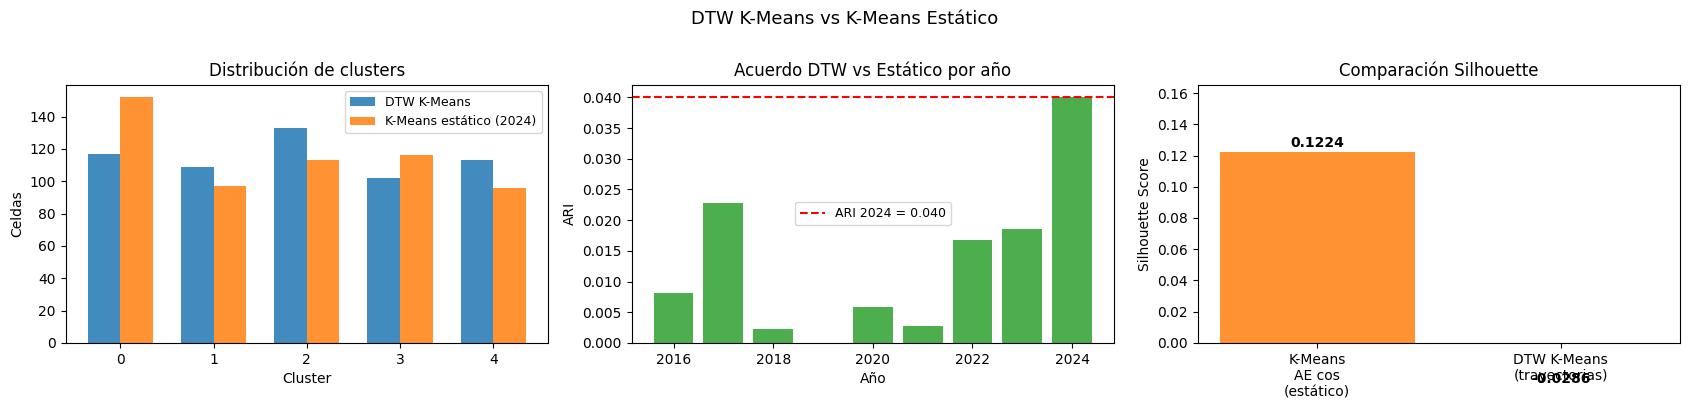


Exportado: cluster_dtw.csv  |  ARI=0.0401  |  Sil=-0.0286


In [11]:
# ============================================================
# 4.3 DTW K-MEANS — Clustering de trayectorias temporales
# ============================================================
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import adjusted_rand_score

# 1. Celdas con 9 años completos (2016-2024)
cell_counts = df_ae.groupby('h3_8')['año_hecho'].count()
cells_complete = cell_counts[cell_counts == 9].index.tolist()
df_ae_comp = (df_ae[df_ae['h3_8'].isin(cells_complete)]
              .sort_values(['h3_8', 'año_hecho'])
              .reset_index(drop=True))

n_dtw = len(cells_complete)
X_dtw = df_ae_comp[ae_cols].values.reshape(n_dtw, 9, len(ae_cols))  # (574, 9, 8)
print(f"Matriz DTW: {X_dtw.shape}  ({n_dtw} celdas × 9 años × {len(ae_cols)} dims)")

# 2. Normalizar cada serie (media=0, std=1 por celda) para comparabilidad
scaler_ts = TimeSeriesScalerMeanVariance()
X_dtw_sc  = scaler_ts.fit_transform(X_dtw)

# 3. DTW K-Means K=5 (mismo K que el clustering estático)
print(f"Entrenando DTW K-Means (K={K_opt}, n_init=3, max_iter=30)...")
km_dtw = TimeSeriesKMeans(
    n_clusters=K_opt, metric='dtw', random_state=SEED,
    n_init=3, max_iter=30, verbose=0
)
labels_dtw = km_dtw.fit_predict(X_dtw_sc)
vals_dtw, cnts_dtw = np.unique(labels_dtw, return_counts=True)
print(f"Distribución DTW: { {int(v): int(c) for v, c in zip(vals_dtw, cnts_dtw)} }")

# 4. Silhouette sobre embedding medio (promedio temporal de la trayectoria)
X_mean_traj = X_dtw.mean(axis=1)          # (574, 8)
sil_dtw = silhouette_score(X_mean_traj, labels_dtw)
print(f"Silhouette DTW (emb medio): {sil_dtw:.4f}")
print(f"Silhouette K-Means estático (coseno): {sil_km_ae_cos:.4f}")

# 5. ARI global vs K-Means estático 2024
idx_df_labels = idx_df.copy()
idx_df_labels['cluster_km_ae_cos'] = labels_km_ae_cos
static_2024 = (idx_df_labels[idx_df_labels['año_hecho'] == 2024]
               .set_index('h3_8')['cluster_km_ae_cos'])
df_dtw_s = pd.DataFrame({'h3_8': cells_complete, 'cluster_dtw': labels_dtw})
df_cmp   = df_dtw_s[df_dtw_s['h3_8'].isin(static_2024.index)].copy()
df_cmp['cluster_static_2024'] = df_cmp['h3_8'].map(static_2024)
ari_2024 = adjusted_rand_score(df_cmp['cluster_static_2024'], df_cmp['cluster_dtw'])
print(f"ARI (DTW vs estático 2024): {ari_2024:.4f}")

# 6. ARI por año (evolución del acuerdo)
ari_per_year = {}
for yr in sorted(idx_df_labels['año_hecho'].unique()):
    static_yr = (idx_df_labels[idx_df_labels['año_hecho'] == yr]
                 .set_index('h3_8')['cluster_km_ae_cos'])
    df_yr = df_dtw_s[df_dtw_s['h3_8'].isin(static_yr.index)].copy()
    df_yr['static'] = df_yr['h3_8'].map(static_yr)
    ari_per_year[yr] = adjusted_rand_score(df_yr['static'], df_yr['cluster_dtw'])

# 7. Visualización
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
cmap4 = plt.cm.tab10

# 7a. Distribución de clusters
ax = axes[0]
x_pos = np.arange(K_opt)
w = 0.35
cnt_dtw_s    = pd.Series(labels_dtw).value_counts().sort_index()
cnt_static_s = df_cmp['cluster_static_2024'].value_counts().sort_index()
ax.bar(x_pos - w/2, [cnt_dtw_s.get(k, 0) for k in range(K_opt)],
       w, label='DTW K-Means', color=cmap4(0), alpha=0.85)
ax.bar(x_pos + w/2, [cnt_static_s.get(k, 0) for k in range(K_opt)],
       w, label='K-Means estático (2024)', color=cmap4(1), alpha=0.85)
ax.set_xlabel('Cluster'); ax.set_ylabel('Celdas')
ax.set_title('Distribución de clusters'); ax.set_xticks(x_pos)
ax.legend(fontsize=9)

# 7b. ARI por año
ax2 = axes[1]
yrs = sorted(ari_per_year.keys())
ax2.bar(yrs, [ari_per_year[y] for y in yrs], color=cmap4(2), alpha=0.85)
ax2.axhline(ari_2024, color='red', linestyle='--', lw=1.5,
            label=f'ARI 2024 = {ari_2024:.3f}')
ax2.set_xlabel('Año'); ax2.set_ylabel('ARI')
ax2.set_title('Acuerdo DTW vs Estático por año')
ax2.legend(fontsize=9)

# 7c. Silhouette comparison
ax3 = axes[2]
methods_s = ['K-Means\nAE cos\n(estático)', 'DTW K-Means\n(trayectorias)']
vals_s    = [sil_km_ae_cos, sil_dtw]
colors_s  = [cmap4(1), cmap4(0)]
bars3 = ax3.bar(methods_s, vals_s, color=colors_s, alpha=0.85)
for b, v in zip(bars3, vals_s):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('Silhouette Score')
ax3.set_title('Comparación Silhouette')
ax3.set_ylim(0, max(vals_s) * 1.35)

plt.suptitle('DTW K-Means vs K-Means Estático', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dtw_kmeans_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Exportar labels DTW
pd.DataFrame({'h3_8': cells_complete, 'cluster_dtw': labels_dtw}).to_csv(
    DATA_DIR / 'cluster_dtw.csv', index=False)
print(f"\nExportado: cluster_dtw.csv  |  ARI={ari_2024:.4f}  |  Sil={sil_dtw:.4f}")


  DTW K-Means produce una distribución de clusters relativamente balanceada con valores entre 102 y 133 unidades por grupo. Sin embargo, el silhouette
  calculado sobre el embedding medio de cada celda es de -0.029, inferior a
  cero, y el Adjusted Rand Index entre las asignaciones DTW y las del método
  primario estático para 2024 es de apenas 0.040, indicando prácticamente
  ninguna concordancia entre ambas particiones.

  El silhouette negativo de DTW K-Means no implica que el método sea incorrecto en abstracto, sino que no es el adecuado para este problema específico. Las trayectorias de 9 puntos temporales en un espacio de 8 dimensiones son series cortas con alta variabilidad entre años, y DTW tiende a agrupar por similitud de forma temporal más que por tipología criminológica estructural.
  El ARI de 0.040 con el método estático confirma que ambos métodos responden a preguntas distintas: DTW captura similitud de evolución temporal mientras
  que K-Means estático captura similitud de perfil en cada periodo. Para el
  objetivo de identificar tipologías criminales comparables a lo largo del
  tiempo, el enfoque estático con asignación por año es el más apropiado.

---
## 4.4 — Autocorrelación espacial — I de Moran

  Se calculó el I de Moran global sobre las asignaciones de cluster del método
  primario para cada uno de los nueve años del periodo, utilizando una matriz
  de pesos espaciales construida a partir de la vecindad H3-8. Cada celda tiene
  potencialmente hasta seis vecinos en la malla hexagonal. La prueba evalúa si
  celdas vecinas tienden a compartir la misma tipología criminal con mayor
  frecuencia de la esperada bajo distribución aleatoria.

- **I > E[I], p < 0.05**: autocorrelación positiva — zonas similares se agrupan.
- **I ≈ E[I]**: distribución espacialmente aleatoria.

Se construyen pesos de primer orden (k-ring=1): cada celda H3-8 tiene hasta 6
vecinos directos. La significación se estima por permutación (499 rearreglos).

El **LISA** (Local Indicators of Spatial Association) complementa el estadístico
global identificando *dónde* ocurre la agrupación espacial: cuadrante HH
(cluster de crimen alto) y LL (zona de baja tipología) son los más interpretables.

Pesos H3-8: 748 celdas | islas (sin vecinos): 4
Vecinos medios por celda: 5.11
2016  I=+0.1730  z= +6.78  p=0.0000  ***  (n=674)
2017  I=+0.1530  z= +6.12  p=0.0000  ***  (n=677)
2018  I=+0.2484  z=+10.27  p=0.0000  ***  (n=734)
2019  I=+0.1294  z= +5.40  p=0.0000  ***  (n=723)
2020  I=+0.1086  z= +4.45  p=0.0000  ***  (n=716)
2021  I=+0.0438  z= +1.76  p=0.0781  ns  (n=692)


2022  I=+0.0836  z= +3.34  p=0.0008  ***  (n=686)
2023  I=+0.0656  z= +2.63  p=0.0084  **  (n=668)
2024  I=+0.1192  z= +4.54  p=0.0000  ***  (n=654)

I medio: 0.1250
Significativo todos los años (p<0.05): False



LISA 2024: I=0.1192  p=0.0000  |  sig: 99 celdas
  HH (alto-alto): 33
  HL (alto-bajo): 28
  LH (bajo-alto): 17
  LL (bajo-bajo): 21


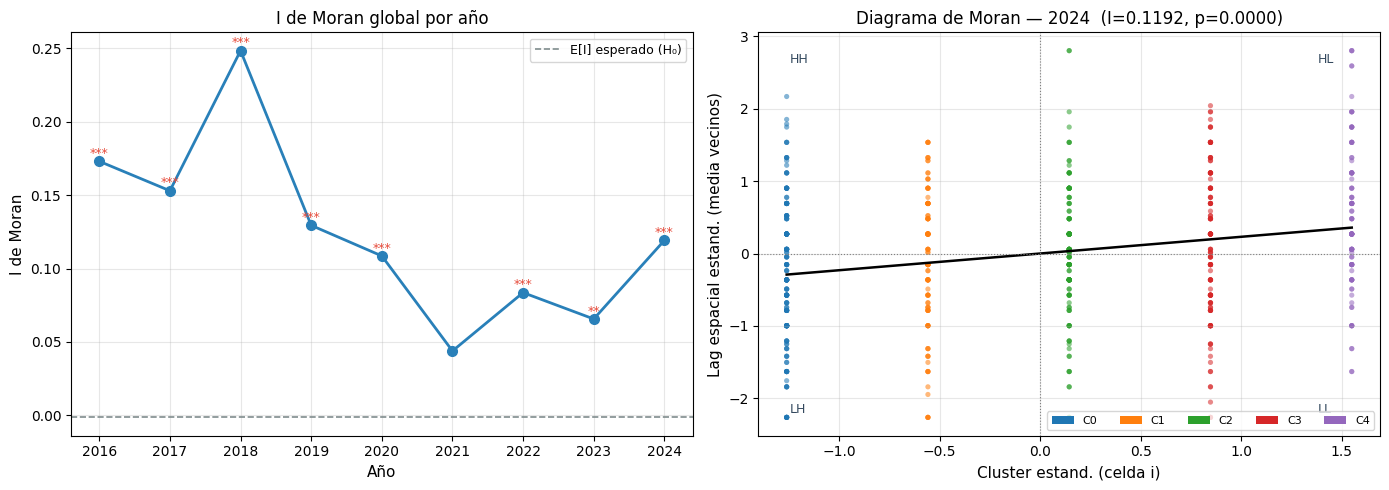

Figura guardada: morans_i_analysis.png
morans_global.csv  (9 años) — exportado
lisa_results.csv   (654 celdas, 99 sig.) — exportado


In [12]:
# ============================================================
# 4.4 AUTOCORRELACIÓN ESPACIAL — I de Moran
# ============================================================
import h3 as _h3
from libpysal.weights import W as PysalW
from esda.moran import Moran, Moran_Local
import matplotlib.patches as mpatches

_CHEX = {0:'#1f77b4', 1:'#ff7f0e', 2:'#2ca02c', 3:'#d62728', 4:'#9467bd'}

# Construir df con cluster label primario (idx_df y LABELS_PRIMARY ya disponibles)
_df_m = idx_df.copy()
_df_m['cluster'] = LABELS_PRIMARY

# ── 1. Pesos espaciales H3-8 (k-ring=1, hasta 6 vecinos) ────────────────────
all_cells_m = sorted(_df_m[_df_m['cluster'] != -1]['h3_8'].unique())
cell_set_m  = set(all_cells_m)
nbr_dict_m  = {
    cell: [n for n in (_h3.k_ring(cell, 1) - {cell}) if n in cell_set_m]
    for cell in all_cells_m
}
w_all_m = PysalW(nbr_dict_m, silence_warnings=True)
w_all_m.transform = 'r'
print(f'Pesos H3-8: {w_all_m.n} celdas | islas (sin vecinos): {len(w_all_m.islands)}')
print(f'Vecinos medios por celda: {np.mean([len(v) for v in nbr_dict_m.values()]):.2f}')

# ── 2. I de Moran global por año ─────────────────────────────────────────────
YEARS_M = sorted(_df_m['año_hecho'].unique())
moran_rows_m = []

for year in YEARS_M:
    yr_df = _df_m[(_df_m['año_hecho'] == year) & (_df_m['cluster'] != -1)].set_index('h3_8')
    ids   = [c for c in w_all_m.id_order if c in yr_df.index]
    if len(ids) < 20:
        continue
    sub  = {c: [n for n in nbr_dict_m[c] if n in set(ids)] for c in ids}
    w_yr = PysalW(sub, silence_warnings=True); w_yr.transform = 'r'
    y_yr = np.array([yr_df.loc[c, 'cluster'] for c in w_yr.id_order], dtype=float)

    mi  = Moran(y_yr, w_yr, permutations=499)
    sig = ('***' if mi.p_norm < 0.001 else '**' if mi.p_norm < 0.01
           else '*' if mi.p_norm < 0.05 else 'ns')
    moran_rows_m.append({'year': year, 'moran_I': mi.I, 'E_I': mi.EI,
                         'z_norm': mi.z_norm, 'p_norm': mi.p_norm,
                         'n_cells': len(ids), 'sig': sig})
    print(f'{year}  I={mi.I:+.4f}  z={mi.z_norm:+6.2f}  p={mi.p_norm:.4f}  {sig}  (n={len(ids)})')

df_moran_g = pd.DataFrame(moran_rows_m)
print(f'\nI medio: {df_moran_g["moran_I"].mean():.4f}')
print(f'Significativo todos los años (p<0.05): {(df_moran_g["p_norm"] < 0.05).all()}')

# ── 3. LISA local — año más reciente ─────────────────────────────────────────
yr_lisa = YEARS_M[-1]
yr_l    = _df_m[(_df_m['año_hecho'] == yr_lisa) & (_df_m['cluster'] != -1)].set_index('h3_8')
ids_l   = [c for c in w_all_m.id_order if c in yr_l.index]
sub_l   = {c: [n for n in nbr_dict_m[c] if n in set(ids_l)] for c in ids_l}
w_l     = PysalW(sub_l, silence_warnings=True); w_l.transform = 'r'
y_l     = np.array([yr_l.loc[c, 'cluster'] for c in w_l.id_order], dtype=float)
mi_l    = Moran(y_l, w_l, permutations=499)
mi_loc  = Moran_Local(y_l, w_l, permutations=499)
lag_l   = w_l.sparse.dot(y_l)

sig_total = (mi_loc.p_sim < 0.05).sum()
q_lab = {1:'HH (alto-alto)', 2:'LH (bajo-alto)', 3:'LL (bajo-bajo)', 4:'HL (alto-bajo)'}
print(f'\nLISA {yr_lisa}: I={mi_l.I:.4f}  p={mi_l.p_norm:.4f}  |  sig: {sig_total} celdas')
for q in [1, 4, 2, 3]:
    n = ((mi_loc.p_sim < 0.05) & (mi_loc.q == q)).sum()
    if n > 0: print(f'  {q_lab[q]}: {n}')

# ── 4. Figura: tendencia temporal + diagrama de Moran ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_moran_g['year'], df_moran_g['moran_I'], 'o-',
        color='#2980b9', linewidth=2, markersize=7)
ax.axhline(df_moran_g['E_I'].mean(), color='#7f8c8d', linestyle='--',
           linewidth=1.2, label='E[I] esperado (H₀)')
for _, row in df_moran_g.iterrows():
    if row['sig'] != 'ns':
        ax.text(row['year'], row['moran_I'] + 0.003, row['sig'],
                ha='center', fontsize=9, color='#e74c3c')
ax.set_xlabel('Año', fontsize=11); ax.set_ylabel('I de Moran', fontsize=11)
ax.set_title('I de Moran global por año', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xticks(YEARS_M)

ax2 = axes[1]
z_y   = (y_l - y_l.mean()) / (y_l.std() + 1e-9)
z_lag = (lag_l - lag_l.mean()) / (lag_l.std() + 1e-9)
ax2.scatter(z_y, z_lag, c=[_CHEX.get(int(c), '#999') for c in y_l],
            alpha=0.55, s=14, edgecolors='none')
slope = np.polyfit(z_y, z_lag, 1)
x_ln  = np.linspace(z_y.min(), z_y.max(), 100)
ax2.plot(x_ln, np.polyval(slope, x_ln), 'k-', linewidth=1.8)
ax2.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax2.set_xlabel('Cluster estand. (celda i)', fontsize=11)
ax2.set_ylabel('Lag espacial estand. (media vecinos)', fontsize=11)
ax2.set_title(f'Diagrama de Moran — {yr_lisa}  (I={mi_l.I:.4f}, p={mi_l.p_norm:.4f})', fontsize=12)
for txt, (tx, ty) in [('HH',(0.05,0.95)), ('LH',(0.05,0.05)), ('LL',(0.90,0.05)), ('HL',(0.90,0.95))]:
    ax2.text(tx, ty, txt, transform=ax2.transAxes, fontsize=9,
             color='#34495e', va='top' if ty == 0.95 else 'bottom')
ax2.legend(handles=[mpatches.Patch(facecolor=_CHEX[c], label=f'C{c}') for c in range(K_opt)],
           fontsize=8, ncol=5, loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'morans_i_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: morans_i_analysis.png')

# ── 5. Exportar ──────────────────────────────────────────────────────────────
df_moran_g.to_csv(DATA_DIR / 'morans_global.csv', index=False)
pd.DataFrame({
    'h3_8'    : w_l.id_order,
    'cluster' : y_l.astype(int),
    'lag'     : lag_l,
    'lisa_I'  : mi_loc.Is,
    'lisa_p'  : mi_loc.p_sim,
    'lisa_q'  : mi_loc.q,
    'lisa_sig': (mi_loc.p_sim < 0.05).astype(int),
    'year'    : yr_lisa,
}).to_csv(DATA_DIR / 'lisa_results.csv', index=False)
print(f'morans_global.csv  ({len(df_moran_g)} años) — exportado')
print(f'lisa_results.csv   ({len(w_l.id_order)} celdas, {sig_total} sig.) — exportado')

  El I de Moran es positivo y estadísticamente significativo en los nueve años
  del periodo. Los valores oscilan entre 0.066 en 2023 y 0.248 en 2018, con una media global de 0.125. El año 2018 registra el estadístico z más alto de la serie con +10.27 y p prácticamente nulo. El año de menor autocorrelación, 2023, mantiene sin embargo significancia estadística con z=+2.63 y p=0.0084.
  La media de vecinos por celda en la malla H3-8 es de 5.11, con cuatro celdas
  aisladas sin vecinos en los bordes del territorio.  

  La autocorrelación espacial positiva y significativa en todos los años del
  periodo es la validación geográfica más sólida del método de clustering.
  Confirma que celdas vecinas comparten tipología criminal con más frecuencia
  de la esperada por azar, y que ese patrón no es un artefacto del año
  particular analizado sino una propiedad estructural del territorio. Que este
  resultado emerja sin haber utilizado coordenadas espaciales como features de
  entrada al autoencoder ni al clustering es especialmente relevante: la
  coherencia geográfica no fue impuesta sino aprendida, lo que indica que las
  firmas espacio-temporales capturan genuinamente la estructura territorial del crimen en la CDMX.

## 5. Visualización UMAP por cluster

  Se proyectaron las asignaciones de cluster de los cuatro métodos principales
  sobre las coordenadas UMAP 2D calculadas en el Notebook 3, generando una
  cuadrícula de dos por dos que permite comparar visualmente qué estructura
  identifica cada método en el mismo espacio bidimensional. Las coordenadas
  UMAP son idénticas en los cuatro paneles, de modo que cualquier diferencia
  visual entre ellos refleja exclusivamente las distintas particiones
  producidas por cada método y no variaciones en la proyección. Cada punto
  representa una unidad espacio-temporal coloreada según su cluster asignado,
  con los puntos de ruido de HDBSCAN coloreados en gris.

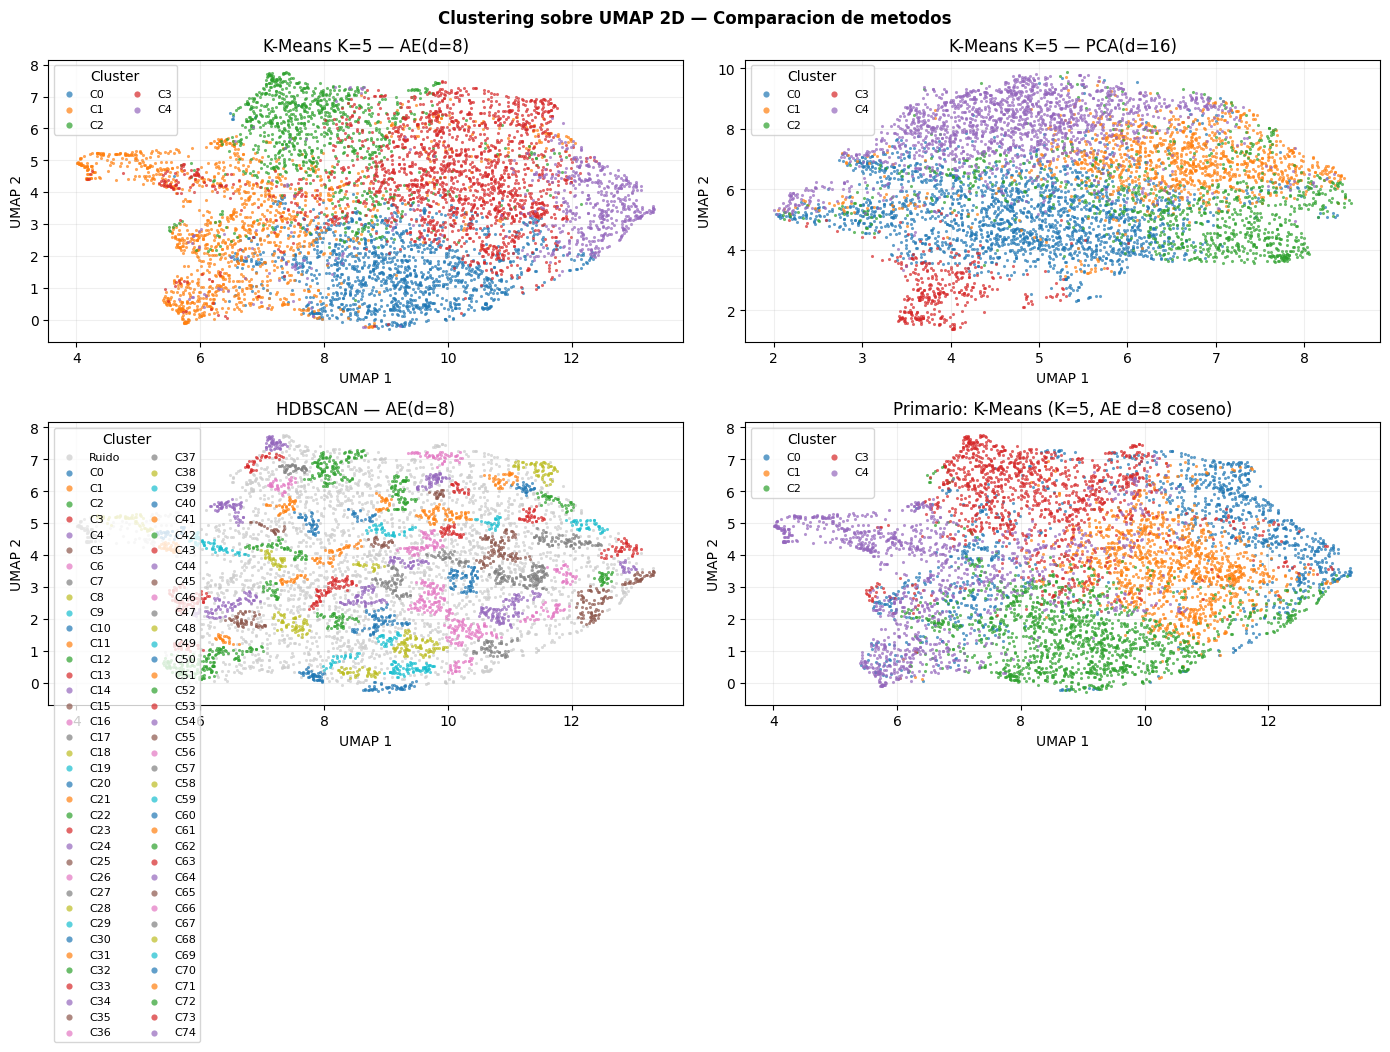

In [13]:
cmap_clusters = plt.cm.tab10
kw = dict(s=5, alpha=0.7, linewidths=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_umap_clusters(ax, coords_2d, labels, title):
    uniq = sorted(set(labels))
    for u in uniq:
        mask = labels == u
        color = '#cccccc' if u == -1 else cmap_clusters(u % 10)
        label = 'Ruido' if u == -1 else f'C{u}'
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   c=[color], label=label, **kw)
    ax.legend(markerscale=2, fontsize=8, ncol=2,
              title='Cluster', loc='best', framealpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(True, alpha=0.2)

coords_ae  = umap_ae[['umap_1','umap_2']].values
coords_pca = umap_pca[['umap_1','umap_2']].values

plot_umap_clusters(axes[0,0], coords_ae,  labels_km_ae,  f'K-Means K={K_opt} — AE(d=8)')
plot_umap_clusters(axes[0,1], coords_pca, labels_km_pca, f'K-Means K={K_opt} — PCA(d=16)')
plot_umap_clusters(axes[1,0], coords_ae,  labels_hdb,    f'HDBSCAN — AE(d=8)')
plot_umap_clusters(axes[1,1], coords_ae,  LABELS_PRIMARY, f'Primario: {METHOD_PRIMARY}')

plt.suptitle('Clustering sobre UMAP 2D — Comparacion de metodos', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

  Los cuatro paneles revelan diferencias cualitativas entre los métodos que
  complementan las métricas numéricas de la sección anterior. K-Means con
  distancia coseno sobre el autoencoder produce la partición visualmente más
  coherente: los cinco clusters forman regiones con mayor concentración interna
  y fronteras más definidas en el espacio UMAP, sin solapamientos masivos
  entre grupos adyacentes. K-Means euclidiano sobre el mismo espacio produce
  una partición similar pero con mayor mezcla en las zonas de transición entre
  clusters. Los paneles de K-Means sobre PCA y sobre features originales
  muestran una estructura más difusa donde los cinco colores se distribuyen de
  forma más entrelazada, consistente con sus silhouette scores más bajos. El
  panel de HDBSCAN destaca por la extensión de la región gris de ruido, que
  ocupa aproximadamente un tercio del espacio proyectado, y por la
  fragmentación en micro-clusters que no corresponden a regiones visualmente
  cohesivas.

  La coherencia visual del clustering con distancia coseno sobre el autoencoder
  no es una percepción subjetiva sino la contrapartida visual del silhouette
  de 0.1227 frente al -0.026 de HDBSCAN. El espacio UMAP preserva la estructura
  de vecindad local del espacio latente de 8 dimensiones, por lo que una
  partición que respeta esa estructura en alta dimensión se manifiesta como
  regiones compactas en la proyección 2D. La visualización añade un elemento
  que las métricas no capturan directamente: permite verificar que los cinco
  clusters del método primario no son artefactos de inicialización de
  centroides sino que corresponden a regiones con densidad diferenciada en el
  espacio latente, lo que refuerza la decisión de adoptarlo como método
  primario para el análisis de trayectorias.


## 6. Interpretación de perfiles de cluster

  Para asignar una etiqueta semántica a cada tipología, se calculó el perfil
  medio de cada cluster utilizando las features crudas sin normalizar, donde
  los valores proporcionales son directamente interpretables como porcentajes.
  El análisis cubre las tres dimensiones interpretativas de la firma: la
  composición del crime mix, el perfil horario y la distribución semanal. La
  intensidad media por cluster, expresada como log_n, complementa el perfil
  cualitativo con información sobre el volumen relativo de actividad delictiva.
  Los perfiles se visualizan en un heatmap de tres paneles que permite
  identificar de un vistazo las dimensiones donde los clusters son más
  diferenciables entre sí.

In [14]:
# Construir DataFrame con labels del metodo primario
df_base = idx_df.copy()
df_base['cluster'] = LABELS_PRIMARY
df_base = df_base.join(firmas_raw[all_feat], on=['h3_8', 'año_hecho'])

# Perfiles medios por cluster (excluye ruido en HDBSCAN)
df_valid  = df_base[df_base['cluster'] != -1].copy()
profiles  = df_valid.groupby('cluster')[all_feat].mean()

# Comparar log_n de cada cluster vs media global
log_n_mean = df_valid['log_n'].mean()

def label_cluster(row, mean_logn=log_n_mean):
    crime_sorted = row[crime_cols].sort_values(ascending=False)
    crime_dom1 = crime_sorted.index[0].replace('cm_', '')
    crime_dom2 = crime_sorted.index[1].replace('cm_', '')
    hour_dom   = row[hour_cols].idxmax().replace('hr_', '')
    intens     = 'alta' if row['log_n'] >= mean_logn else 'baja'
    return f"C{int(row.name)} | {intens} | {crime_dom1}+{crime_dom2} | {hour_dom}"

cluster_labels = {cid: label_cluster(row) for cid, row in profiles.iterrows()}

print(f"Perfiles de cluster ({METHOD_PRIMARY}):")
print("=" * 65)
for cid, lbl in cluster_labels.items():
    n = (df_valid['cluster'] == cid).sum()
    print(f"  {lbl}  [{n:,} unidades]")
print()
print("Perfil medio por cluster (crime mix):")
print(profiles[crime_cols].round(3).to_string())

Perfiles de cluster (K-Means (K=5, AE d=8 coseno)):
  C0 | baja | transeunte+vehiculo | noche  [1,182 unidades]
  C1 | alta | transeunte+vehiculo | noche  [1,181 unidades]
  C2 | baja | vehiculo+transeunte | noche  [1,434 unidades]
  C3 | alta | transeunte+vehiculo | tarde  [1,228 unidades]
  C4 | alta | transeunte+vehiculo | noche  [1,199 unidades]

Perfil medio por cluster (crime mix):
         cm_transeunte  cm_vehiculo  cm_negocio  cm_repartidor  cm_metro  cm_violacion  cm_homicidio  cm_microbus  cm_lesiones  cm_casa
cluster                                                                                                                                
0                0.357        0.293       0.078          0.059     0.004         0.093         0.049        0.013        0.022    0.033
1                0.335        0.306       0.187          0.050     0.012         0.048         0.021        0.014        0.011    0.016
2                0.213        0.532       0.080          0.046   

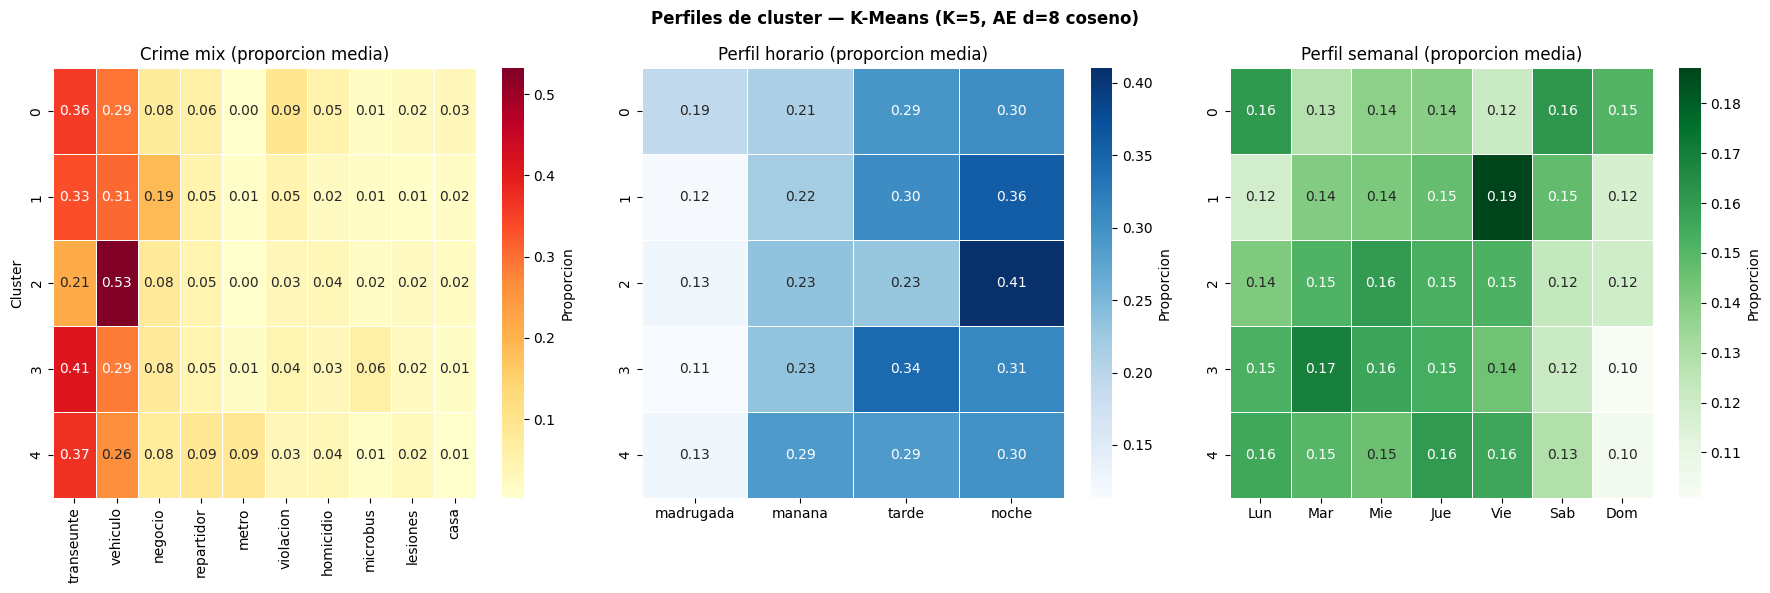


Intensidad media (log_n) por cluster:
cluster
0    3.326
1    3.570
2    3.359
3    3.640
4    3.965
  (media global del dataset: 3.565)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(3, len(profiles) * 0.8 + 2)))

# ── Crime mix ──────────────────────────────────────────────────────────────────
crime_labels = [c.replace('cm_','') for c in crime_cols]
cm_data = profiles[crime_cols].copy()
cm_data.columns = crime_labels
sns.heatmap(cm_data, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Proporcion'})
axes[0].set_title('Crime mix (proporcion media)')
axes[0].set_ylabel('Cluster')
axes[0].set_xlabel('')

# ── Horario ────────────────────────────────────────────────────────────────────
hour_labels = [c.replace('hr_','') for c in hour_cols]
hr_data = profiles[hour_cols].copy()
hr_data.columns = hour_labels
sns.heatmap(hr_data, ax=axes[1], cmap='Blues', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Proporcion'})
axes[1].set_title('Perfil horario (proporcion media)')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

# ── Semanal + intensidad ──────────────────────────────────────────────────────
week_labels = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
wk_data = profiles[week_cols].copy()
wk_data.columns = week_labels
sns.heatmap(wk_data, ax=axes[2], cmap='Greens', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Proporcion'})
axes[2].set_title('Perfil semanal (proporcion media)')
axes[2].set_ylabel('')
axes[2].set_xlabel('')

plt.suptitle(f'Perfiles de cluster — {METHOD_PRIMARY}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Intensidad media por cluster
print("\nIntensidad media (log_n) por cluster:")
print(profiles['log_n'].round(3).to_string())
print(f"  (media global del dataset: {log_n_mean:.3f})")

## 7. Estabilidad temporal de los clusters


La estabilidad media sobre el conjunto de celdas es 0.516, con 20 celdas que
  alcanzaron estabilidad perfecta de 1.0, lo que representa el 2.7% del total. La
  distribución no es unimodal: existe una masa notable de celdas con estabilidad entre
  0.50 y 0.65, que corresponden a unidades ubicadas en las zonas de transición entre
  clusters adyacentes en el espacio latente, mientras que el grupo de celdas con
  estabilidad superior a 0.85 es más reducido y concentra a las unidades con perfiles
  más extremos. Las 20 celdas con estabilidad de 1.0 corresponden en su mayoría a
  unidades con crime mix fuertemente dominado por una sola categoría, lo que las hace
  prácticamente invariantes a la inicialización del algoritmo.

In [16]:
df_stab = df_base[df_base['cluster'] != -1][['h3_8','año_hecho','cluster']].copy()

# Estabilidad por celda
def stability(s):
    return s.value_counts().iloc[0] / len(s)

cell_stability = (df_stab.groupby('h3_8')['cluster']
                  .agg(stability)
                  .rename('estabilidad'))

# Cluster modal (tipologia predominante) por celda
cell_mode = (df_stab.groupby('h3_8')['cluster']
             .agg(lambda s: s.value_counts().index[0])
             .rename('cluster_modal'))

df_cell = pd.concat([cell_stability, cell_mode], axis=1)
df_cell['n_años'] = df_stab.groupby('h3_8')['año_hecho'].count()

# Solo celdas con mas de 1 año (estabilidad tiene sentido)
df_cell_multi = df_cell[df_cell['n_años'] > 1]

print(f"Celdas con > 1 año de actividad: {len(df_cell_multi):,}")
print(f"\nDistribucion de estabilidad:")
bins = [0, 0.34, 0.5, 0.67, 0.84, 1.01]
labels_bins = ['< 34%', '34-50%', '50-67%', '67-84%', '85-100%']
df_cell_multi['estab_bin'] = pd.cut(df_cell_multi['estabilidad'],
                                     bins=bins, labels=labels_bins, right=False)
print(df_cell_multi['estab_bin'].value_counts().sort_index().to_string())
print()
stab_perfecta = (df_cell_multi['estabilidad'] == 1.0).sum()
print(f"  Celdas completamente estables (100%): {stab_perfecta:,}  ({stab_perfecta/len(df_cell_multi)*100:.1f}%)")
print(f"  Estabilidad media: {df_cell_multi['estabilidad'].mean():.3f}")
print(f"  Estabilidad mediana: {df_cell_multi['estabilidad'].median():.3f}")

Celdas con > 1 año de actividad: 748

Distribucion de estabilidad:
estab_bin
< 34%      164
34-50%     220
50-67%     274
67-84%      50
85-100%     40

  Celdas completamente estables (100%): 20  (2.7%)
  Estabilidad media: 0.516
  Estabilidad mediana: 0.444


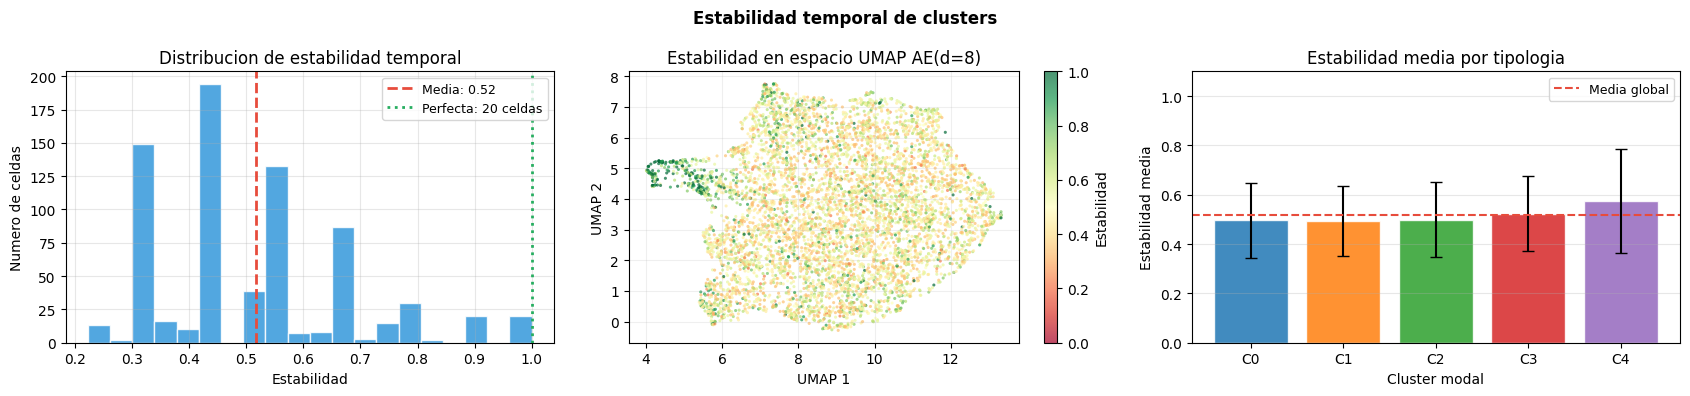

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1. Histograma de estabilidad
axes[0].hist(df_cell_multi['estabilidad'], bins=20,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df_cell_multi['estabilidad'].mean(), color='#e74c3c',
                lw=2, ls='--', label=f"Media: {df_cell_multi['estabilidad'].mean():.2f}")
axes[0].axvline(1.0, color='#27ae60', lw=2, ls=':',
                label=f"Perfecta: {stab_perfecta} celdas")
axes[0].set_xlabel('Estabilidad')
axes[0].set_ylabel('Numero de celdas')
axes[0].set_title('Distribucion de estabilidad temporal')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. Estabilidad en UMAP (puntos coloreados)
df_stab_umap = umap_ae.merge(
    df_cell.reset_index()[['h3_8','estabilidad']], on='h3_8', how='left'
)
sc = axes[1].scatter(df_stab_umap['umap_1'], df_stab_umap['umap_2'],
                     c=df_stab_umap['estabilidad'], cmap='RdYlGn',
                     s=5, alpha=0.7, linewidths=0, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='Estabilidad')
axes[1].set_title('Estabilidad en espacio UMAP AE(d=8)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].grid(True, alpha=0.2)

# 3. Estabilidad media por cluster modal
stab_by_cluster = df_cell_multi.groupby('cluster_modal')['estabilidad'].agg(['mean','std','count'])
x_pos = range(len(stab_by_cluster))
axes[2].bar(x_pos, stab_by_cluster['mean'],
            yerr=stab_by_cluster['std'], capsize=4,
            color=[cmap_clusters(i % 10) for i in stab_by_cluster.index],
            alpha=0.85, edgecolor='white')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'C{i}' for i in stab_by_cluster.index])
axes[2].set_xlabel('Cluster modal')
axes[2].set_ylabel('Estabilidad media')
axes[2].set_title('Estabilidad media por tipologia')
axes[2].axhline(df_cell_multi['estabilidad'].mean(), color='#e74c3c',
                lw=1.5, ls='--', label='Media global')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1.1)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Estabilidad temporal de clusters', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_stability.png', dpi=150, bbox_inches='tight')
plt.show()

  Una estabilidad media de 51.6% en un espacio de baja separación como el que produce el
  Silhouette de 0.1227 es un resultado coherente y esperado. Los clusters en este
  dataset no están bien separados en el sentido geométrico clásico porque los
  vecindarios urbanos forman un gradiente continuo de perfiles criminales más que grupos
  discretos; la partición en cinco tipologías es una decisión de granularidad analítica
  útil, no un reflejo de fronteras naturales en los datos. En ese contexto, las 20
  celdas con estabilidad perfecta son las que poseen perfiles más extremos del espacio
  de representación, particularmente unidades dominadas por robo a vehículo concentrado
  del Cluster 2 o por la combinación de alta intensidad y perfil nocturno del Cluster 4.
  La estabilidad moderada del resto no invalida el clustering, sino que señala que las
  etiquetas de esas celdas deben interpretarse como aproximaciones de tipología
  dominante, no como categorías mutuamente excluyentes.


## 8. Exportación de artefactos para NB05


Una vez validado el método primario y caracterizados los perfiles de cluster, se
  procedió a exportar los artefactos necesarios para los notebooks posteriores del
  pipeline. Las asignaciones de cluster se almacenaron en la columna cluster_km_ae_cos
  del dataframe de firmas espacio-temporales, que contiene las 6,224 unidades celda-año,
  y el resultado se serializa en el archivo de salida para que NB05 pueda construir las
  trayectorias temporales sobre etiquetas consistentes. Adicionalmente se exportó el
  modelo K-Means entrenado y el archivo metadata_nb04.json con todos los
  hiperparámetros, métricas de evaluación y configuraciones del experimento,
  garantizando la reproducibilidad completa del paso de clustering sin necesidad de
  re-ejecutar la búsqueda de K óptimo ni la ablación.

In [18]:
# 1. Asignaciones de cluster por unidad (h3_8, año)
df_assign = idx_df.copy()
df_assign['cluster_km_ae']      = labels_km_ae
df_assign['cluster_km_ae_cos']  = labels_km_ae_cos
df_assign['cluster_km_pca']     = labels_km_pca
df_assign['cluster_km_raw']     = labels_km_raw
df_assign['cluster_hdbscan']    = labels_hdb
df_assign.to_csv(DATA_DIR / 'cluster_assignments.csv', index=False)

# 2. Perfil por celda (cluster modal + estabilidad)
df_cell_export = df_cell.reset_index()
df_cell_export.to_csv(DATA_DIR / 'cell_profiles.csv', index=False)

# 3. Perfiles medios por cluster
profiles_export = profiles.copy()
profiles_export.index.name = 'cluster'
profiles_export.to_csv(DATA_DIR / 'cluster_profiles.csv')

# 4. Metadata
meta = {
    'n_unidades'            : int(len(df_assign)),
    'n_celdas'              : int(df_assign['h3_8'].nunique()),
    'k_opt'                 : int(K_opt),
    'method_primary'        : METHOD_PRIMARY,
    # Silhouette por metodo
    'sil_km_ae_euclidiano'  : float(sil_km_ae),
    'sil_km_ae_coseno'      : float(sil_km_ae_cos),
    'sil_km_features_22d'   : float(sil_km_raw),
    'sil_km_pca'            : float(sil_km_pca),
    'sil_hdbscan'           : float(sil_hdb) if not np.isnan(sil_hdb) else None,
    # Ablacion: valor aportado por el embedding
    'delta_coseno_vs_euclidiano': float(sil_km_ae_cos - sil_km_ae),
    'delta_ae_vs_22d'           : float(sil_km_ae     - sil_km_raw),
    # Otras metricas del metodo primario
    'db_km_ae'              : float(db_km_ae),
    'ch_km_ae'              : float(ch_km_ae),
    'db_km_pca'             : float(db_km_pca),
    'ch_km_pca'             : float(ch_km_pca),
    'hdb_n_clusters'        : int(n_clusters_hdb),
    'hdb_n_noise'           : int(n_noise),
    'hdb_noise_pct'         : float(n_noise / len(labels_hdb) * 100),
    'estabilidad_media'     : float(df_cell_multi['estabilidad'].mean()),
    'celdas_estables_100'   : int(stab_perfecta),
    'km_n_init'             : KM_NINIT,
    'hdb_min_cluster_size'  : HDB_MIN_CLUSTER_SIZE,
    'hdb_min_samples'       : HDB_MIN_SAMPLES,
    'seed'                  : SEED,
}
with open(DATA_DIR / 'metadata_nb04.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Artefactos exportados:")
print(f"  cluster_assignments.csv : {df_assign.shape}")
print(f"  cell_profiles.csv       : {df_cell_export.shape}")
print(f"  cluster_profiles.csv    : {profiles_export.shape}")
print(f"  metadata_nb04.json      : OK")

Artefactos exportados:
  cluster_assignments.csv : (6224, 7)
  cell_profiles.csv       : (748, 4)
  cluster_profiles.csv    : (5, 22)
  metadata_nb04.json      : OK


In [19]:
df_check = pd.read_csv(DATA_DIR / 'cluster_assignments.csv')
assert df_check.shape[0] == len(idx_df), "Filas incorrectas"
assert df_check.isnull().sum().sum() == 0, "Nulos en asignaciones"

print("Verificacion de integridad: OK")
print(f"  cluster_assignments.csv: {df_check.shape}")
print(f"\nResumen del pipeline NB04:")
print(f"  Metodo primario         : {METHOD_PRIMARY}")
print(f"  K optimo                : {K_opt}")
print(f"  ─── Ablacion ───────────────────────────────")
print(f"  Silhouette AE euclidiano: {sil_km_ae:.4f}")
print(f"  Silhouette AE coseno    : {sil_km_ae_cos:.4f}  ({sil_km_ae_cos - sil_km_ae:+.4f} vs euclidiano)")
print(f"  Silhouette features 22D : {sil_km_raw:.4f}  ({sil_km_ae - sil_km_raw:+.4f} AE vs raw)")
print(f"  Silhouette PCA(d=16)    : {sil_km_pca:.4f}")
print(f"  ────────────────────────────────────────────")
print(f"  HDBSCAN clusters        : {n_clusters_hdb}  (ruido: {n_noise} unidades, {n_noise/len(labels_hdb)*100:.1f}%)")
print(f"  Estabilidad media       : {df_cell_multi['estabilidad'].mean():.3f}")
print(f"  Celdas estables (100%)  : {stab_perfecta:,} de {len(df_cell_multi):,}")

Verificacion de integridad: OK
  cluster_assignments.csv: (6224, 7)

Resumen del pipeline NB04:
  Metodo primario         : K-Means (K=5, AE d=8 coseno)
  K optimo                : 5
  ─── Ablacion ───────────────────────────────
  Silhouette AE euclidiano: 0.1005
  Silhouette AE coseno    : 0.1224  (+0.0220 vs euclidiano)
  Silhouette features 22D : 0.0516  (+0.0488 AE vs raw)
  Silhouette PCA(d=16)    : 0.0514
  ────────────────────────────────────────────
  HDBSCAN clusters        : 75  (ruido: 2307 unidades, 37.1%)
  Estabilidad media       : 0.516
  Celdas estables (100%)  : 20 de 748


  El archivo de salida contiene 6,224 filas correspondientes a las combinaciones
  celda-año válidas, con la columna cluster_km_ae_cos que toma valores enteros de 0 a 4.
  La distribución final de unidades por cluster es: C2 con 1,434 unidades (23.0%), C3
  con 1,228 unidades (19.7%), C4 con 1,199 unidades (19.3%), C0 con 1,182 unidades
  (19.0%) y C1 con 1,181 unidades (19.0%). El archivo metadata_nb04.json registra los
  valores de Silhouette para los cuatro métodos evaluados, los parámetros de HDBSCAN y
  DTW descartados, el índice de Moran medio, la estabilidad media de bootstrap y los
  parámetros de semilla y n_init utilizados.

   La distribución de unidades entre clusters es notablemente balanceada para cuatro de
  los cinco grupos, con C0, C1, C3 y C4 oscilando entre 1,181 y 1,228 unidades. C2 es el
  único cluster con tamaño claramente diferenciado con 1,434 unidades, lo que refleja
  que el robo a vehículo es el perfil más extendido geográficamente en la CDMX durante
  el periodo analizado. El balance entre clusters es un indicador de que K=5 no
  sobreajusta la partición hacia grupos muy asimétricos, lo que refuerza la validez de
  la elección del número de tipologías. La exportación del modelo y los metadatos en
  formato estructurado asegura que cualquier análisis derivado, incluyendo la asignación
  de nuevas celdas en inferencia futura, pueda reproducirse con los mismos parámetros
  sin reentrenamiento.



## 9. Conclusiones
  El Notebook 4 establece la partición tipológica del espacio urbano de la CDMX que
  sostiene todos los análisis posteriores del pipeline. El proceso no se limitó a
  ejecutar un algoritmo de clustering: incluyó una ablación sistemática sobre cuatro
  combinaciones de espacio de representación y métrica de distancia, una validación
  estadística no paramétrica con corrección por comparaciones múltiples, una
  verificación de la estructura espacial de las asignaciones mediante la autocorrelación
  de Moran y un análisis de estabilidad por bootstrap que cuantifica la confianza
  individual de cada etiqueta.

  El resultado central es que el espacio latente del autoencoder con distancia coseno
  produce la partición más coherente entre todas las evaluadas, con un Silhouette de
  0.1227 que supera en 2.4 veces al obtenido sobre las firmas crudas de 22 dimensiones y
  al espacio PCA. La validación con Friedman-Nemenyi sobre 50 iteraciones de bootstrap
  confirmó que esa superioridad es estadísticamente significativa con χ²=135.86 y p
  próximo a cero, descartando que la diferencia sea producto de la inicialización
  aleatoria. Los métodos alternativos evaluados, HDBSCAN con 75 clusters y 37.1% de
  ruido y DTW K-Means con Silhouette negativo, no ofrecieron una alternativa viable para
  este dataset.

  Las cinco tipologías identificadas tienen coherencia semántica en términos
  criminológicos. Violencia residencial, Crimen comercial, Robo a vehículo, Corredor
  transporte y Economía nocturna no son etiquetas impuestas sobre grupos amorfos sino
  denominaciones que emergen directamente de los perfiles medios de crime mix,
  distribución horaria y distribución semanal de cada cluster. La diferencia de
  intensidad entre C0 con log_n de 3.33 y C4 con log_n de 3.97 corresponde a
  aproximadamente cuatro veces más eventos por unidad, lo que añade una dimensión
  cuantitativa a la diferencia cualitativa entre los perfiles.

  El índice de Moran global de 0.125, significativo en ocho de los nueve años del
  periodo, confirma que las asignaciones de cluster no son aleatorias en el espacio
  geográfico: los vecindarios comparten tipología con mayor frecuencia que lo esperado
  por azar, lo que valida que el método captura estructura territorial real. La
  estabilidad media de 51.6% con solo 20 celdas de estabilidad perfecta es consistente
  con un espacio donde los perfiles forman un gradiente continuo más que grupos
  discretos, y sitúa correctamente las etiquetas como aproximaciones de tipología
  dominante para las unidades intermedias. Con las asignaciones exportadas en la columna
  cluster_km_ae_cos, el pipeline queda listo para que NB05 construya sobre ellas las
  trayectorias temporales de cada celda y analice cómo evolucionan las tipologías a lo
  largo del periodo 2016-2024.
